In [63]:
import numpy as np
import os
import time
import torch
from torch import nn, optim

import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import sys
sys.path.append(r"C:\Users\Tao Yu\d2lzh_pytorch")
import d2lzh_pytorch as d2l

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

os.environ["CUDA_VISIBLE_DEVICES"] ="0"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.__version__)
print(device)

2.4.0
cuda


In [64]:
print(torch.__version__)
print(torchvision.__version__)

2.4.0
0.19.0


In [65]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, 5), # in_channels, out_channels, kernel_size
            nn.Sigmoid(),
            nn.MaxPool2d(2, 2), # kernel_size, stride
            nn.Conv2d(6, 16, 5),
            nn.Sigmoid(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(16*4*4, 120),
            nn.Sigmoid(),
            nn.Linear(120, 84),
            nn.Sigmoid(),
            nn.Linear(84, 10)
        )

    def forward(self, img):
        feature = self.conv(img)
        output = self.fc(feature.view(img.shape[0], -1))
        return output

In [66]:
net = LeNet()
print(net)

LeNet(
  (conv): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Sigmoid()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Sigmoid()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=120, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [67]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='~/Datasets/MNIST', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='~/Datasets/MNIST', train=False, download=True, transform=transform)

batch_size = 256
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [68]:
# 本函数已保存在d2lzh_pytorch包中方便以后使用。该函数将被逐步改进：它的完整实现将在“图像增广”一节中
def evaluate_accuracy(data_iter, net, device=None):
    if device is None and isinstance(net, torch.nn.Module):
        # 如果没指定device就使用net的device
        device = list(net.parameters())[0].device
    acc_sum, n = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(net, torch.nn.Module):
                net.eval() # 评估模式, 这会关闭dropout
                acc_sum += (net(X.to(device)).argmax(dim=1) == y.to(device)).float().sum().cpu().item()
                net.train() # 改回训练模式
            else: # 自定义的模型, 3.13节之后不会用到, 不考虑GPU
                if('is_training' in net.__code__.co_varnames): # 如果有is_training这个参数
                    # 将is_training设置成False
                    acc_sum += (net(X, is_training=False).argmax(dim=1) == y).float().sum().item() 
                else:
                    acc_sum += (net(X).argmax(dim=1) == y).float().sum().item() 
            n += y.shape[0]
    return acc_sum /n

In [69]:
# 本函数已保存在d2lzh_pytorch包中方便以后使用
def train_ch5(net, train_iter, test_iter, batch_size, optimizer, device, num_epochs):
    net = net.to(device)
    print("training on ", device)
    loss = torch.nn.CrossEntropyLoss()
    batch_count = 0
    for epoch in range(num_epochs): 
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()
        for X, y in train_iter:
            X = X.to(device)
            y = y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            train_l_sum += l.cpu().item()
            train_acc_sum += (y_hat.argmax(dim=1) == y).sum().cpu().item()
            n += y.shape[0]
            batch_count += 1
        test_acc = evaluate_accuracy(test_iter, net)
        print('epoch %d, loss %.4f, train acc %.3f, test acc %.3f, time %.1f sec'
              %(epoch + 1, train_l_sum /batch_count, train_acc_sum / n, test_acc, time.time() - start))

In [70]:
lr, num_epochs = 0.001, 5
optimizer = torch.optim.Adam(net.parameters(), lr=lr)
train_ch5(net, train_iter, test_iter, batch_size, optimizer, device, num_epochs)

training on  cuda
epoch 1, loss 1.9732, train acc 0.327, test acc 0.756, time 8.9 sec
epoch 2, loss 0.2919, train acc 0.844, test acc 0.902, time 8.9 sec
epoch 3, loss 0.1019, train acc 0.914, test acc 0.930, time 9.0 sec
epoch 4, loss 0.0529, train acc 0.938, test acc 0.949, time 8.9 sec
epoch 5, loss 0.0331, train acc 0.951, test acc 0.956, time 9.0 sec


In [71]:
sample_images = []
sample_labels = []
for i, (X, y) in enumerate(test_iter): 
    if i == 0:  
        sample_images = X[:100]  
        sample_labels = y[:100]  
        break

In [72]:
with torch.no_grad():
    net.eval()  
    predictions = net(sample_images.to(device)).argmax(dim=1).cpu()  
    net.train()  

In [73]:
correct = (predictions == sample_labels).sum().item()
accuracy = correct / 100
print(f'Accuracy on 100 test samples: {accuracy:.2%}')

Accuracy on 100 test samples: 97.00%


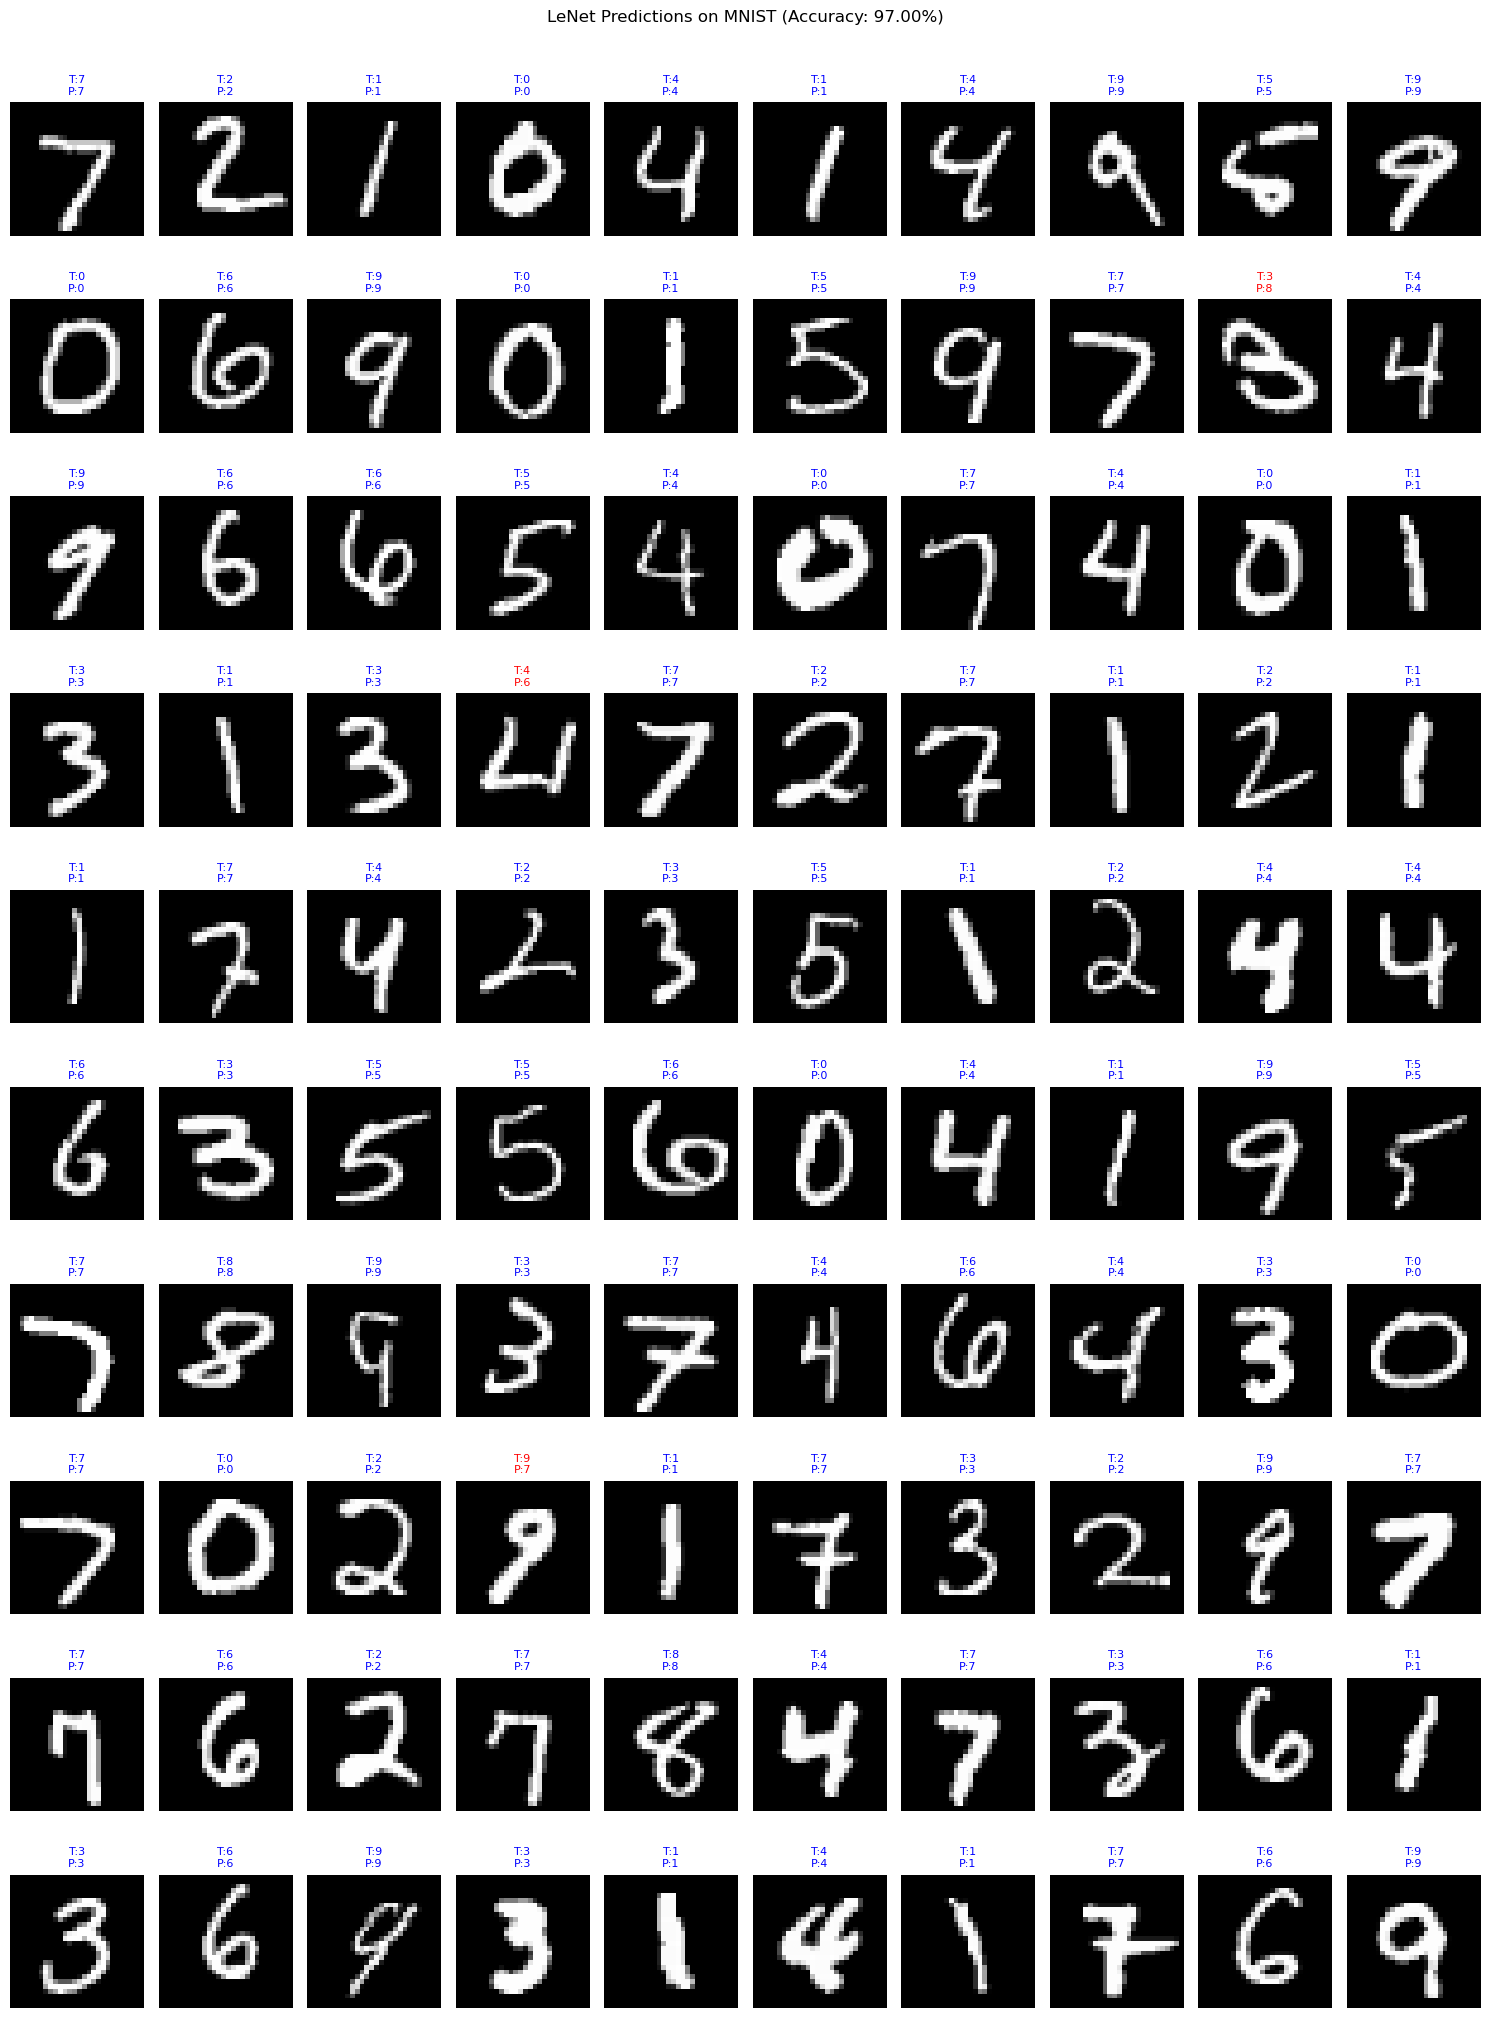

In [74]:
plt.figure(figsize=(15, 20))
n_rows = 10
n_cols = 10
for i in range(100):
    plt.subplot(n_rows, n_cols, i+1)
    img = sample_images[i].squeeze().numpy()  
    
    # 标记预测结果：正确为蓝色，错误为红色
    color = 'blue' if predictions[i] == sample_labels[i] else 'red'
    
    plt.imshow(img, cmap='gray')
    plt.title(f'T:{sample_labels[i]}\nP:{predictions[i]}', color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.suptitle(f'LeNet Predictions on MNIST (Accuracy: {accuracy:.2%})', y=1.02)
plt.show()